In [69]:
#Analysis of fighters for AI Report
#Final Notebook, no draft

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
import openpyxl as oxl

In [68]:
#Task status, to be printed at the end to signify the status of the overall task
status = ['Tasks Resolved', 'Tasks Unresolved', 'Tasks in Pprogress']

In [3]:
#importing dataset
#testing

dataset = pd.read_excel('wrestlers_dataset_final.xlsx')

In [4]:
dataset.head(21)

,fighter_id,name_x,natinality_name,wins,losses,total_matches,win_pct,avg_gained_point,avg_skipped_point,takedown_score,...,durability_score,defense_score_durability,offense_score_durability,takedown_score_durability,passivity_per_fight,overall_score,Completed,unique_matches,name_y,Accomplished
0,22538,Kyle Douglas DAKE,usa,40,3,43,0.93,8.186047,1.441860,0.54,...,0.47,0.07,0.72,0.53,0.17,0.5225,1,30,Kyle Dake,29
1,21973,Rahman Mousa AMOUZADKHALILI,iri,36,4,40,0.90,7.750000,2.000000,0.53,...,0.53,0.17,0.80,0.51,0.25,0.5350,1,33,Rahman Mousa Amouzadkhalili,33
2,22027,Amir Hossein Abbas ZARE,iri,44,3,47,0.94,8.468085,1.234043,0.09,...,0.04,NaN,NaN,NaN,0.50,0.5050,1,36,Amir Hossein Abbas Zare,41
3,21636,Artur ALEKSANYAN,arm,29,6,35,0.83,5.542857,1.314286,0.63,...,0.45,0.00,NaN,NaN,0.56,0.6275,1,28,Artur Aleksanyan,33
4,22562,Hassan Aliazam YAZDANICHARATI,iri,37,3,40,0.93,9.925000,1.325000,0.75,...,0.55,0.89,0.25,0.44,0.11,0.8000,1,35,Hassan Yazdani,39
5,25055,Abubakar KHASLAKHANAU,ain,14,3,17,0.82,7.470588,2.705882,0.91,...,0.52,0.00,0.78,0.81,0.50,0.6650,1,13,Abubakar Khaslakhanau,13
6,21777,Luis Alberto ORTA SANCHEZ,cub,37,6,43,0.86,5.418605,1.720930,0.63,...,0.45,0.11,0.38,NaN,0.47,0.5475,1,33,Luis Alberto Orta Sanchez,34
7,22493,Zelimkhan ABAKAROV,alb,16,5,21,0.76,7.333333,1.809524,0.69,...,0.05,NaN,NaN,NaN,0.17,0.4350,1,16,Zelimkhan Abakarov,16
8,23332,Giorgi MESHVILDISHVILI,aze,6,3,9,0.67,5.444444,1.666667,0.61,...,0.54,0.43,0.51,0.25,0.32,0.6525,1,8,Meşvildişvili Georgi,9
9,25565,Arvi Martin SAVOLAINEN,fin,44,14,58,0.76,5.068966,2.189655,0.74,...,0.53,0.30,0.96,0.55,0.34,0.6825,1,51,Arvi Martin Savolainen,51


In [5]:
dataset.shape

(66, 53)

In [6]:
dataset.dtypes

fighter_id                                  int64
name_x                                     object
natinality_name                            object
wins                                        int64
losses                                      int64
total_matches                               int64
win_pct                                   float64
avg_gained_point                          float64
avg_skipped_point                         float64
takedown_score                            float64
takedown_success_count                    float64
total_takedown_count                      float64
takedown_success_rate                     float64
takedown_per_fight_total                  float64
average_takedown_points_per_fight         float64
single_leg_takedown_count                 float64
single_leg_takedown_success_rate          float64
double_leg_takedown_success_rate          float64
double_leg_takedown_count                 float64
defense_score                             float64


In [7]:
#copying data set to a new dataset 'data'
#dropping id column and object columns

df = pd.DataFrame(dataset)
data = df.drop(['fighter_id','name_x','natinality_name','name_y'], axis='columns')
data

,wins,losses,total_matches,win_pct,avg_gained_point,avg_skipped_point,takedown_score,takedown_success_count,total_takedown_count,takedown_success_rate,...,total_parterre_per_match,durability_score,defense_score_durability,offense_score_durability,takedown_score_durability,passivity_per_fight,overall_score,Completed,unique_matches,Accomplished
0,40,3,43,0.93,8.186047,1.441860,0.54,24.0,37.0,0.65,...,1.87,0.47,0.07,0.72,0.53,0.17,0.5225,1,30,29
1,36,4,40,0.90,7.750000,2.000000,0.53,30.0,43.0,0.70,...,0.52,0.53,0.17,0.80,0.51,0.25,0.5350,1,33,33
2,44,3,47,0.94,8.468085,1.234043,0.09,18.0,41.0,0.44,...,0.78,0.04,NaN,NaN,NaN,0.50,0.5050,1,36,41
3,29,6,35,0.83,5.542857,1.314286,0.63,3.0,3.0,1.00,...,2.36,0.45,0.00,NaN,NaN,0.56,0.6275,1,28,33
4,37,3,40,0.93,9.925000,1.325000,0.75,91.0,190.0,0.48,...,1.89,0.55,0.89,0.25,0.44,0.11,0.8000,1,35,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,12,11,23,0.52,4.956522,3.391304,0.47,29.0,105.0,0.28,...,0.86,0.64,0.77,0.16,0.09,0.12,0.5850,1,22,23
62,35,18,53,0.66,5.000000,2.641509,0.00,7.0,68.0,0.10,...,0.40,0.49,0.91,0.00,0.12,0.17,0.3850,1,15,10
63,15,19,34,0.44,4.235294,4.558824,0.12,24.0,153.0,0.16,...,0.23,0.64,0.78,0.17,0.06,0.11,0.5075,1,31,31
64,17,15,32,0.53,4.312500,3.031250,0.48,7.0,12.0,0.58,...,0.29,0.24,NaN,0.42,NaN,0.50,0.3075,1,14,12


In [60]:
#task 1: Statistical Analysis of each column volunteerily
#analysis from .describe() and custom percentiles [0.5, 0.1, 0.9]

def statistical_analysis(data, column):
    """
       The function titled statistical_analysis(x,y) is responsible for:
       1) Descriptive Statistical Analysis eg: mean, median etc. & 
       2) Creating a new table (using pandas' DataFrame) titled "Informatics" to display the statistics.
       3) Returning the Informatics 

       Arguments: 
       1) x: data (a pandas' DataFrame containing the dataset) & 
       2) y: a particular column (string) within x.

       code courtesy: salarsalarov, code assistance: namigjafarov
    """

    refined_dataset = data.dropna(subset = [column])
    descriptive_stats = refined_dataset[column].describe()
    print(f"\nStat for '{column}':")
    
    #thresholding with custom percentiles
    dataset_median = refined_dataset[column].median()
    vth_percentile = np.percentile(refined_dataset[column],5)
    xth_percentile = np.percentile(refined_dataset[column],10)
    xcth_percentile = np.percentile(refined_dataset[column],90)

    analytics = {
        "Informatics": [
            descriptive_stats['count'],
            descriptive_stats['mean'],
            dataset_median,
            descriptive_stats['std'],
            descriptive_stats['min'],
            descriptive_stats['max'],
            vth_percentile, 
            xth_percentile,
            descriptive_stats['25%'],
            descriptive_stats['50%'],
            descriptive_stats['75%'],
            xcth_percentile
        ]
    }

    #data visualizaton
    #making custom labels for data visualizaton
    informatics = pd.DataFrame(analytics, index = ['Count','Average', 'Median', 'Standard Deviation', 'Minimum', 'Maximum', '5%', '10%', '25%', '50%', '75%', '90%'])    

    return informatics

In [57]:
#calling the function with a particular column
#eg: 'wins' column

statistical_analysis(data, 'wins')


Stat for 'wins':


,Informatics
Count,66.000000
Average,25.848485
Median,24.000000
Standard Deviation,12.984301
Minimum,4.000000
Maximum,49.000000
5%,7.000000
10%,9.500000
25%,15.250000
50%,24.000000


In [10]:
#Targeted task 1: Returning the informatics for columns titled: "total_takedown_count" & "takedown_success_rate" 

targeted_columns = ['total_takedown_count', 'takedown_success_rate']

for col in targeted_columns:
    print(statistical_analysis(data.copy(), col))


Stat for 'total_takedown_count':
                    Informatics
Count                 65.000000
Average               62.553846
Median                42.000000
Standard Deviation    63.453731
Minimum                3.000000
Maximum              370.000000
5%                     9.200000
10%                   12.400000
25%                   25.000000
50%                   42.000000
75%                   74.000000
90%                  143.600000

Stat for 'takedown_success_rate':
                    Informatics
Count                 65.000000
Average                0.514923
Median                 0.480000
Standard Deviation     0.202794
Minimum                0.100000
Maximum                1.000000
5%                     0.206000
10%                    0.262000
25%                    0.350000
50%                    0.480000
75%                    0.650000
90%                    0.796000


In [70]:
#task 2: Data Visualization for the informatics through histograms & normal distributions

def data_visualization(data, column): 
    """
       The function titled data_visualization(x,y) is responsible for two visuals:
       1) Histogram & 2) Normal Distribution

       Argumnets: 
       1) x: data (a pandas' DataFrame containing the dataset) & 2) y: a particular column (string) within x.

       code courtesy: salarsalarov
    """
    
    refined_dataset = data.dropna(subset=[column])
    print(f"\nVisualization for '{column}': ")

    plt.clf()
    #histogram (l.h.s)
    plt.subplot(1,2,1)
    sns.histplot(refined_dataset[column])
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {column}")

    #normal distribution (r.h.s)
    plt.subplot(1,2,2)
    n, bins, patches = plt.hist(refined_dataset[column], density = True, alpha = 0.05)

    mu = refined_dataset[column].mean()
    sigma = refined_dataset[column].std()
    x = np.linspace(bins.min(), bins.max(), 100)
    y = norm.pdf(x, mu, sigma)

    plt.plot(x,y, label = "Normal Distribution")
    plt.xlabel(column)
    plt.ylabel("Probability Density")
    plt.title(f"Normal Distribution for {column}")
    plt.legend()
    plt.grid(True)
    plt.subplots_adjust(left= -0.30)
    plt.show()
    


Visualization for 'wins': 


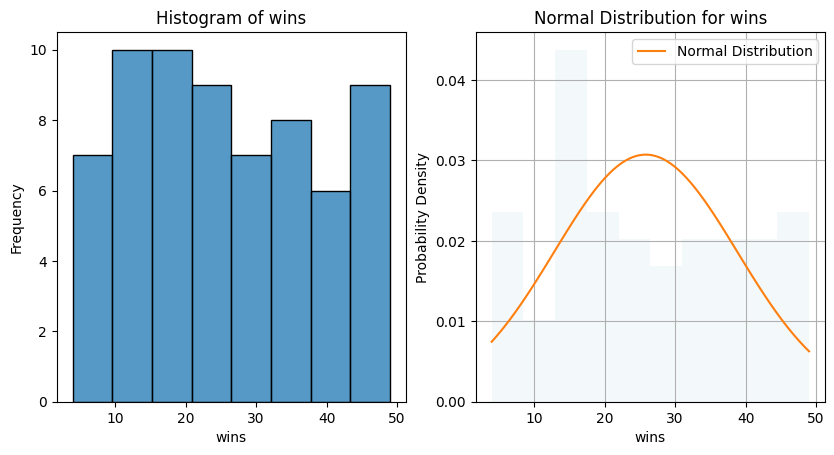

In [58]:
#calling the function with a particular column
#eg: 'wins' column

data_visualization(data, 'wins')


Visualization for 'total_takedown_count': 


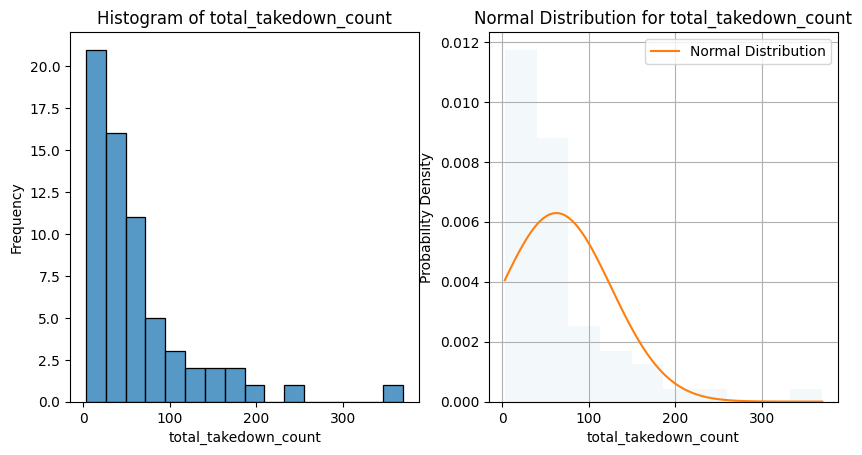


Visualization for 'takedown_success_rate': 


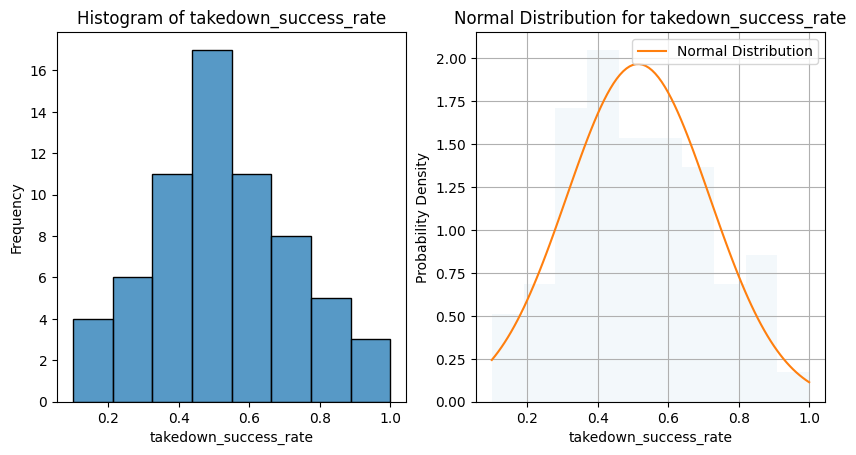

In [65]:
#Targeted Task 2: Data Visualization for the columns titled: "total_takedown_count" & "takedown_success_rate" 

targeted_columns = ['total_takedown_count', 'takedown_success_rate']

for col in targeted_columns:
    data_visualization(data.copy(), col)


In [73]:
#Successful Operations 
status[0]

'Tasks Resolved'